<a href="https://colab.research.google.com/github/rudra680/Algorithmic-Trading-Backtester.ipynb/blob/main/self.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install yfinance

##Why not using if else statement to run the code for both NSE and BSE?
On Yahoo Finance, the ticker for Tata Motors on the BSE isn't just the name; it’s often their numeric script code.

NSE Ticker: TATAMOTORS.NS (This almost always works).

BSE Ticker: 500570.BO (BSE uses 6-digit codes for many legacy stocks).

In [23]:
import yfinance as yf
import pandas as pd

Stock = input("Enter Stock Name! ").strip().upper()

ticker = f"{Stock}.NS"

# 5 years of daily data into a Pandas DataFrame called 'df'
stock_target = yf.Ticker(ticker)
df = stock_target.history(period="5y")

df.index = df.index.tz_localize(None)
df.head()

Enter Stock Name! reliance


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-03-15,970.365607,974.378430,943.363730,956.241211,16698099,0.0,0.0
2021-03-16,958.553686,963.994887,950.165234,952.477722,13873801,0.0,0.0
2021-03-17,951.321487,953.565972,922.777952,931.959961,19210236,0.0,0.0
2021-03-18,939.917660,945.313525,907.315966,910.988770,20647480,0.0,0.0
2021-03-19,902.781606,950.323858,899.063466,944.043823,41787429,0.0,0.0


## **Why not using open wala data**
1. The "Consensus" vs. The "Reaction"
The Close Price: This is considered the most important price of the day. It represents the final, settled agreement between buyers and sellers after all the day's news has been digested. It filters out the intraday panic.

The Open Price: The Open is highly volatile. It is often just a chaotic reaction to whatever news happened overnight while the market was closed. It can "gap" up or down wildly.

2. The Real-World Execution Problem (Slippage)
In quantitative finance, there is a massive difference between a backtest on paper and actual trading.

If your model uses the Close: The market closes at 3:30 PM. Your code downloads the final Close price, calculates the moving averages at 3:31 PM, and says, "Buy." You have all night to place your buy order for the next morning. It is clean and easy.

If your model uses the Open: The market opens at 9:15 AM. You don't know the Open price until that exact second. If your code calculates the average and says "Buy" at 9:15:01 AM, the price might have already jumped by 2% before your order goes through. This delay is called slippage, and it destroys algorithm profits in the real world.

In [24]:
import numpy as np

# 1. Price Moving Averages
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# 2. NEW: Volume Moving Average (20-day baseline)
df['Vol_SMA_20'] = df['Volume'].rolling(window=20).mean()

# 3. NEW: The Upgraded Trading Signal with Volume Filter
condition_1 = df['SMA_50'] > df['SMA_200']
condition_2 = df['Volume'] > df['Vol_SMA_20']

df['Signal'] = np.where(condition_1 & condition_2, 1, 0)

# 4. Clean up the NaN rows
df = df.dropna()



#Operands are not aligned error

earlier a error was coming i.e df[volume] and df[vol_SMA_20] their format was not same since we get a multiindex on its column by yfinance an a very simple formatted column. so we can remove this error by :

Fix #1: The Clean Extraction Method (Recommended)
Instead of forcing Pandas to deal with the messy sub-headers, we change how we ask Yahoo Finance for the data in Phase 1. By using the .history() method instead of .download(), it gives us perfectly flat, normal columns right from the start.

Fix #2: The Pandas "Flattening" Hack
If you ever want to stick with yf.download() but you need to destroy those annoying sub-headers, you can literally tell Pandas to drop the bottom level of the column names.
df = yf.download(ticker, period="5y")

 (This destroys the "RELIANCE.NS" sub-headers and flattens the table)

df.columns = df.columns.droplevel(1)

##What does the two Returns represents?
* Stock return = a

This is the "Benchmark." It means that if you had simply bought the stock and held it (a "Buy and Hold" strategy), your money would have grown by 'a' times.

* Strategy Return = b

This is the performance of your trading logic (the "Strategy"). It means your specific strategy grew your money by b times.

**Underperformance if a > b ( it is better to just buy and hold)**


In [27]:
# 1. Calculate the daily percentage return of the stock itself
df['Stock_Returns'] = df['Close'].pct_change()

# 2. Calculate your Strategy Returns (Shift the signal by 1 day to avoid "cheating")
df['Strategy_Returns'] = df['Stock_Returns'] * df['Signal'].shift(1)

# 3. Calculate the Cumulative Returns (How $1 would grow over the 5 years)
df['Cumulative_Stock'] = (1 + df['Stock_Returns']).cumprod()
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns']).cumprod()

print("Total Stock Return: ", df['Cumulative_Stock'].iloc[-1])
print("Total Strategy Return: ", df['Cumulative_Strategy'].iloc[-1])

Total Stock Return:  1.263599006724139
Total Strategy Return:  1.281760788041657




*   The alpha=0.5 in the code? That makes the raw stock price line semi-transparent.
*  We are not buying the "Short" stock only working with long strategy whch means either we are fully invested or we have full cash inn hand.  



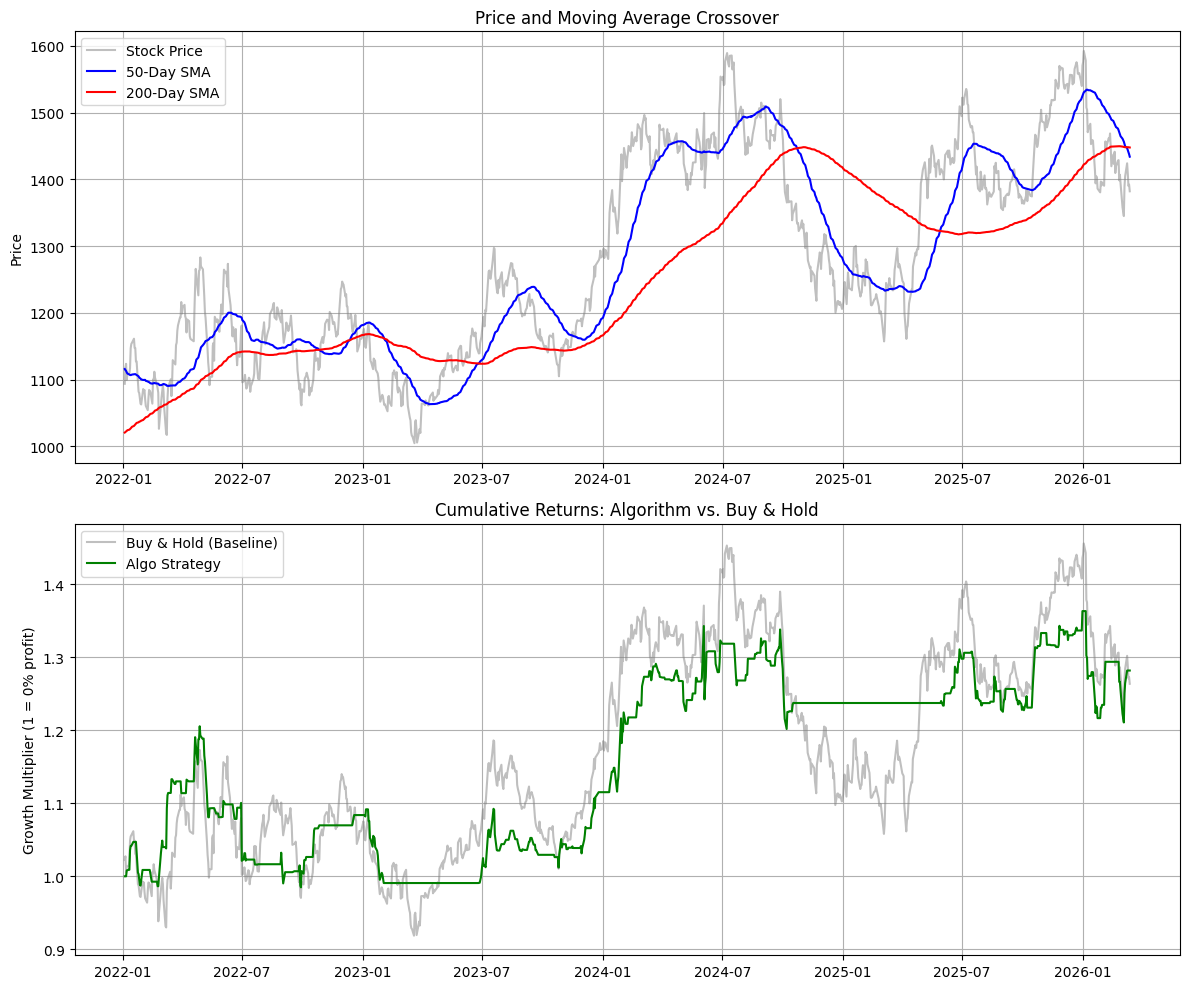

In [28]:
import matplotlib.pyplot as plt

# 1. Set up the canvas: We want 2 charts stacked on top of each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- CHART 1: The Price & Moving Averages ---
ax1.plot(df.index, df['Close'], label='Stock Price', color='grey', alpha=0.5)
ax1.plot(df.index, df['SMA_50'], label='50-Day SMA', color='blue')
ax1.plot(df.index, df['SMA_200'], label='200-Day SMA', color='red')
ax1.set_title('Price and Moving Average Crossover')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)

# --- CHART 2: The Performance Scorecard ---
ax2.plot(df.index, df['Cumulative_Stock'], label='Buy & Hold (Baseline)', color='grey', alpha=0.5)
ax2.plot(df.index, df['Cumulative_Strategy'], label='Algo Strategy', color='green')
ax2.set_title('Cumulative Returns: Algorithm vs. Buy & Hold')
ax2.set_ylabel('Growth Multiplier (1 = 0% profit)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()